# City Day Air Quality Analysis
This project analyzes air quality data of different cities using python.
The objective is to understand pollution levels, identify most polluted cities, ans study trends ovet time using data analysis techniques.

## Introduction

Air pollution is one of the major environmental issues affecting human health.
This dataset contains daily air quality index (AQI) values of various cities.

In this project we perform:
1.  Data cleaning
2.  Handling missing values
3.  City-wise AQI analysis
4.  Year-wise trend analysis
5.  Top and least polluted cities
6.  Correlation analysis
7.  Visualization using graphs

## Objective
The main objectives of this project are:
1. To analyze air quality of different cities.
2. To find most polluted and least polluted cities.
3. To study AQI trend over time.
4. To visualize pollution patterns

## Tools and Library used
1. Python
2. Pandas
3. NumPy
4. Matplotlib
5. Seaborn

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
import pandas as pd
df = pd.read_csv("city_day.csv")

In [6]:
print("First 5 Rows")
print(df.head())

First 5 Rows
        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  01-01-2015    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  02-01-2015    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  03-01-2015    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  04-01-2015    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  05-01-2015    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  


In [7]:
print(df.columns)

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object')


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [9]:
print("Last 5 Rows")
print(df.tail())

Last 5 Rows
                City        Date  PM2.5   PM10    NO    NO2    NOx    NH3  \
29526  Visakhapatnam  27-06-2020  15.02  50.94  7.68  25.06  19.54  12.47   
29527  Visakhapatnam  28-06-2020  24.38  74.09  3.42  26.06  16.53  11.99   
29528  Visakhapatnam  29-06-2020  22.91  65.73  3.45  29.53  18.33  10.71   
29529  Visakhapatnam  30-06-2020  16.64  49.97  4.05  29.26  18.80  10.03   
29530  Visakhapatnam  01-07-2020  15.00  66.00  0.40  26.85  14.05   5.20   

         CO    SO2     O3  Benzene  Toluene  Xylene   AQI    AQI_Bucket  
29526  0.47   8.55  23.30     2.24    12.07    0.73  41.0          Good  
29527  0.52  12.72  30.14     0.74     2.21    0.38  70.0  Satisfactory  
29528  0.48   8.42  30.96     0.01     0.01    0.00  68.0  Satisfactory  
29529  0.52   9.84  28.30     0.00     0.00    0.00  54.0  Satisfactory  
29530  0.59   2.10  17.05      NaN      NaN     NaN  50.0          Good  


In [10]:
print(df.describe)

<bound method NDFrame.describe of                 City        Date  PM2.5   PM10     NO    NO2    NOx    NH3  \
0          Ahmedabad  01-01-2015    NaN    NaN   0.92  18.22  17.15    NaN   
1          Ahmedabad  02-01-2015    NaN    NaN   0.97  15.69  16.46    NaN   
2          Ahmedabad  03-01-2015    NaN    NaN  17.40  19.30  29.70    NaN   
3          Ahmedabad  04-01-2015    NaN    NaN   1.70  18.48  17.97    NaN   
4          Ahmedabad  05-01-2015    NaN    NaN  22.10  21.42  37.76    NaN   
...              ...         ...    ...    ...    ...    ...    ...    ...   
29526  Visakhapatnam  27-06-2020  15.02  50.94   7.68  25.06  19.54  12.47   
29527  Visakhapatnam  28-06-2020  24.38  74.09   3.42  26.06  16.53  11.99   
29528  Visakhapatnam  29-06-2020  22.91  65.73   3.45  29.53  18.33  10.71   
29529  Visakhapatnam  30-06-2020  16.64  49.97   4.05  29.26  18.80  10.03   
29530  Visakhapatnam  01-07-2020  15.00  66.00   0.40  26.85  14.05   5.20   

          CO    SO2      O3  

In [11]:
print(df.isnull().sum())

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [12]:
df.fillna(method='ffill',inplace=True)

/tmp/ipykernel_13239/4116506308.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


In [13]:
city_avg= df.groupby('City')['AQI'].mean()
print("/nAverage AQI by City")
print(city_avg)

/nAverage AQI by City
City
Ahmedabad             423.472993
Aizawl                 35.371681
Amaravati              91.778128
Amritsar              119.909910
Bengaluru              93.790941
Bhopal                129.200692
Brajrajnagar          145.627932
Chandigarh             96.105263
Chennai               112.503733
Coimbatore             72.955959
Delhi                 258.632653
Ernakulam              92.314815
Gurugram              227.184038
Guwahati              139.539841
Hyderabad             105.960618
Jaipur                132.808797
Jorapokhar            143.390077
Kochi                 103.691358
Kolkata               135.331695
Lucknow               209.797909
Mumbai                 87.637631
Patna                 229.198601
Shillong               52.951613
Talcher               157.393514
Thiruvananthapuram     74.510791
Visakhapatnam         118.522572
Name: AQI, dtype: float64


In [14]:
print("/nTop Polluted cities")
print(city_avg)

/nTop Polluted cities
City
Ahmedabad             423.472993
Aizawl                 35.371681
Amaravati              91.778128
Amritsar              119.909910
Bengaluru              93.790941
Bhopal                129.200692
Brajrajnagar          145.627932
Chandigarh             96.105263
Chennai               112.503733
Coimbatore             72.955959
Delhi                 258.632653
Ernakulam              92.314815
Gurugram              227.184038
Guwahati              139.539841
Hyderabad             105.960618
Jaipur                132.808797
Jorapokhar            143.390077
Kochi                 103.691358
Kolkata               135.331695
Lucknow               209.797909
Mumbai                 87.637631
Patna                 229.198601
Shillong               52.951613
Talcher               157.393514
Thiruvananthapuram     74.510791
Visakhapatnam         118.522572
Name: AQI, dtype: float64


In [15]:
Least_polluted = city_avg.sort_values().head(15)
print("/nLeast polluted cities")
print(Least_polluted)

/nLeast polluted cities
City
Aizawl                 35.371681
Shillong               52.951613
Coimbatore             72.955959
Thiruvananthapuram     74.510791
Mumbai                 87.637631
Amaravati              91.778128
Ernakulam              92.314815
Bengaluru              93.790941
Chandigarh             96.105263
Kochi                 103.691358
Hyderabad             105.960618
Chennai               112.503733
Visakhapatnam         118.522572
Amritsar              119.909910
Bhopal                129.200692
Name: AQI, dtype: float64


In [16]:
df['Date']=pd.to_datetime(df['Date'],
dayfirst=True)
df['Year']=df['Date'].dt.year

In [17]:
yearly_aqi= df.groupby('Year')['AQI'].mean()
print(yearly_aqi)

Year
2015    171.386224
2016    193.825762
2017    180.853700
2018    175.412765
2019    154.159683
2020    112.923375
Name: AQI, dtype: float64


In [18]:
print("/nMin AQI by city")
print(df.groupby('City')['AQI'].min())

/nMin AQI by city
City
Ahmedabad             48.0
Aizawl                18.0
Amaravati             20.0
Amritsar              20.0
Bengaluru             20.0
Bhopal                37.0
Brajrajnagar          22.0
Chandigarh            26.0
Chennai               30.0
Coimbatore            26.0
Delhi                 29.0
Ernakulam             55.0
Gurugram              38.0
Guwahati              25.0
Hyderabad             22.0
Jaipur                43.0
Jorapokhar            27.0
Kochi                 51.0
Kolkata               26.0
Lucknow               39.0
Mumbai                40.0
Patna                 53.0
Shillong              14.0
Talcher               13.0
Thiruvananthapuram    32.0
Visakhapatnam         23.0
Name: AQI, dtype: float64


In [19]:
print("/nMax AQI by city")
print(df.groupby('City')['AQI'].max())

/nMax AQI by city
City
Ahmedabad             2049.0
Aizawl                 119.0
Amaravati              312.0
Amritsar               869.0
Bengaluru              352.0
Bhopal                 312.0
Brajrajnagar           355.0
Chandigarh             335.0
Chennai                449.0
Coimbatore             120.0
Delhi                  716.0
Ernakulam              180.0
Gurugram               891.0
Guwahati               956.0
Hyderabad              737.0
Jaipur                 457.0
Jorapokhar             604.0
Kochi                  277.0
Kolkata                475.0
Lucknow                707.0
Mumbai                 307.0
Patna                  619.0
Shillong               182.0
Talcher                570.0
Thiruvananthapuram     230.0
Visakhapatnam          387.0
Name: AQI, dtype: float64


In [20]:
print("/nCity & Year AQI")
print(df['AQI_Bucket'].value_counts())

/nCity & Year AQI
AQI_Bucket
Satisfactory    10468
Moderate         9680
Poor             3108
Very Poor        3018
Good             1817
Severe           1412
Name: count, dtype: int64


In [21]:
print("/nCity & Year AQI")
print(df.groupby(['City','Year'])['AQI'].mean())

/nCity & Year AQI
City           Year
Ahmedabad      2015    320.270030
               2016    335.254098
               2017    398.550685
               2018    626.106849
               2019    516.424658
                          ...    
Visakhapatnam  2016    102.581522
               2017    136.035616
               2018    121.983562
               2019    122.728767
               2020     84.327869
Name: AQI, Length: 103, dtype: float64


In [22]:
city_avg=df.groupby('City')['AQI'].mean()
top_polluted=city_avg.sort_values(ascending=False).head(15)

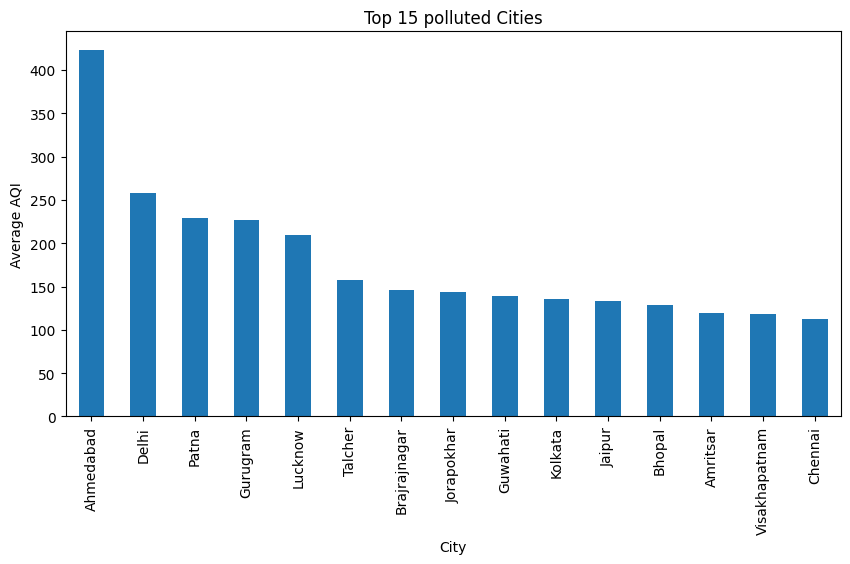

In [23]:
top_polluted.plot(kind='bar',figsize=(10,5))
plt.title("Top 15 polluted Cities")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.show()

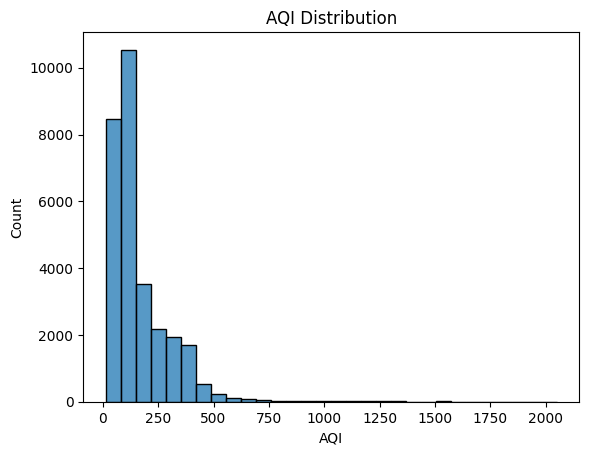

In [24]:
sns.histplot(df['AQI'],bins=30)
plt.title('AQI Distribution')
plt.show()

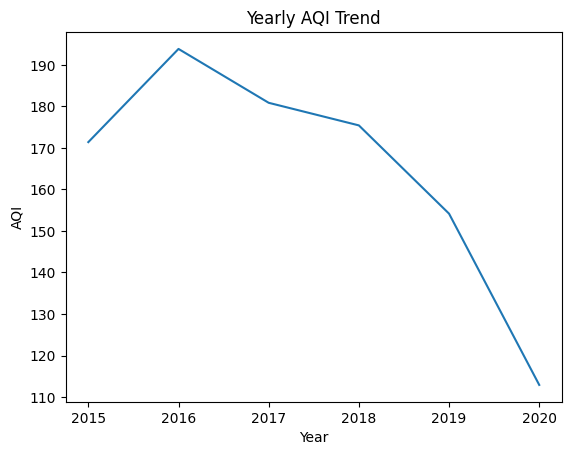

In [25]:
yearly_aqi.plot()
plt.title("Yearly AQI Trend")
plt.ylabel("AQI")
plt.show()

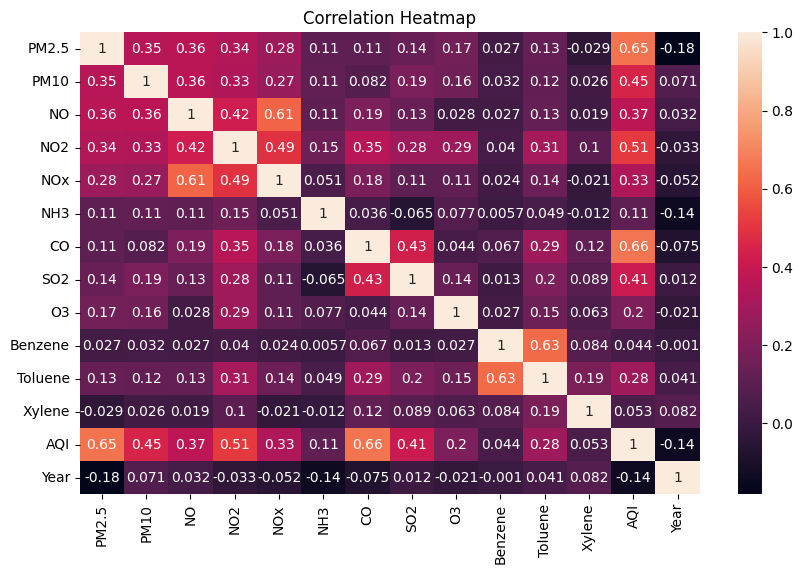

In [27]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()


In [28]:
print("/nFinal insights")
print("Most Polluted City:",city_avg.idxmax())
print("Least Polluted City:",city_avg.idxmin())
print("Pollution varies across cities.")
print("Some cities show consistently high AQI.")
print("PM2.5 and PM10 strongly impact AQI.")

/nFinal insights
Most Polluted City: Ahmedabad
Least Polluted City: Aizawl
Pollution varies across cities.
Some cities show consistently high AQI.
PM2.5 and PM10 strongly impact AQI.


## Conclusion

From the analysis, we observed that air quality varies significantly across cities.
Some cities show consistently high AQI levels indicating poor air quality.
The AQI trend over years shows fluctuation in pollution levels.

Correlation analysis suggests that particulate matter such as PM2.5 and PM10
have strong influence on AQI values.

This project helps in understanding pollution patterns and highlights the need
for environmental control measures to improve air quality.

## Final Insights

1. Pollution level varies city to city
2. Some cities are highly polluted
3. AQI mostly falls in moderate to poor category
4. PM2.5 and PM10 strongly impact AQI
5. Pollution trend changes over time